<a href="https://colab.research.google.com/github/Messaoudichahrazadamira/Role-2-Intermediate-Model-CNN-/blob/main/Role2_CNN_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Role 2 — Intermediate Model (CNN)
## CIFAR-10 Image Classification Benchmark



##  Cell 1 — استيراد المكتبات

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# التحقق من GPU
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# أسماء الفئات في CIFAR-10
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


##  Cell 2 — تحميل ومعالجة البيانات

In [ ]:
# ── تحميل CIFAR-10 ──
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# ── Normalization: [0,255] → [0,1] ──
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32')       / 255.0

# ── Train / Validation Split: 90% / 10% ──
val_size    = int(0.1 * len(X_train_full))
X_val       = X_train_full[:val_size]
y_val       = y_train_full[:val_size]
X_train     = X_train_full[val_size:]
y_train     = y_train_full[val_size:]

print(f'Train set:      {X_train.shape}  — {len(X_train)} images')
print(f'Validation set: {X_val.shape}  — {len(X_val)} images')
print(f'Test set:       {X_test.shape}  — {len(X_test)} images')
print(f'Image shape:    {X_train.shape[1:]}  (32x32 RGB)')
print(f'Classes:        {CLASS_NAMES}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train set:      (45000, 32, 32, 3)  — 45000 images
Validation set: (5000, 32, 32, 3)  — 5000 images
Test set:       (10000, 32, 32, 3)  — 10000 images
Image shape:    (32, 32, 3)  (32x32 RGB)
Classes:        ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


##  Cell 3 — بناء معمارية CNN

In [ ]:
def build_cnn(input_shape=(32, 32, 3), num_classes=10):
    """
    CNN Architecture for CIFAR-10
    ─────────────────────────────
    Block 1 : Conv(32) → Conv(32) → MaxPool → Dropout(0.25)
    Block 2 : Conv(64) → Conv(64) → MaxPool → Dropout(0.25)
    Head    : Flatten → Dense(512) → Dropout(0.5) → Softmax(10)
    """
    model = models.Sequential(name='CNN_CIFAR10')

    # ── Block 1 ──────────────────────────────────────────
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same', input_shape=input_shape,
                            name='conv1_1'))
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same', name='conv1_2'))
    model.add(layers.MaxPooling2D((2, 2), name='pool1'))
    model.add(layers.Dropout(0.25, name='drop1'))

    # ── Block 2 ──────────────────────────────────────────
    model.add(layers.Conv2D(64, (3, 3), activation='relu',
                            padding='same', name='conv2_1'))
    model.add(layers.Conv2D(64, (3, 3), activation='relu',
                            padding='same', name='conv2_2'))
    model.add(layers.MaxPooling2D((2, 2), name='pool2'))
    model.add(layers.Dropout(0.25, name='drop2'))

    # ── Classifier Head ──────────────────────────────────
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(512, activation='relu', name='dense1'))
    model.add(layers.Dropout(0.5, name='drop3'))
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model

# عرض ملخص النموذج
model_summary = build_cnn()
model_summary.summary()

Model: "CNN_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,362 (8.27 MB)

 Trainable params: 2,168,362 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 4 — مقارنة المحسّنات (Optimizer Comparison)

In [ ]:
# ── تعريف المحسّنات ──────────────────────────────────────
OPTIMIZERS = {
    'SGD':     tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Adam':    tf.keras.optimizers.Adam(learning_rate=0.001),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=0.001),
    'Adagrad': tf.keras.optimizers.Adagrad(learning_rate=0.01),
}

EPOCHS     = 30
BATCH_SIZE = 64

all_histories = {}
all_results   = {}

for name, opt in OPTIMIZERS.items():
    print(f'\n{"="*50}')
    print(f'  Training CNN with optimizer: {name}')
    print(f'{"="*50}')

    # بناء نموذج جديد لكل محسّن
    model = build_cnn()
    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Early stopping لتوفير الوقت
    early_stop = callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=1
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    all_histories[name] = history
    all_results[name]   = {
        'model':     model,
        'test_acc':  test_acc,
        'test_loss': test_loss,
        'epochs_run': len(history.history['loss'])
    }

    print(f'  → Test Accuracy : {test_acc:.4f}')
    print(f'  → Test Loss     : {test_loss:.4f}')
    print(f'  → Epochs run    : {len(history.history["loss"])}/{EPOCHS}')


  Training CNN with optimizer: SGD
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.2944 - loss: 1.9266 - val_accuracy: 0.4500 - val_loss: 1.5451
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4603 - loss: 1.4856 - val_accuracy: 0.5468 - val_loss: 1.2996
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5347 - loss: 1.2889 - val_accuracy: 0.6042 - val_loss: 1.1510
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5928 - loss: 1.1413 - val_accuracy: 0.6466 - val_loss: 0.9963
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6315 - loss: 1.0280 - val_accuracy: 0.6844 - val_loss: 0.9102
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6680 - loss: 0.9345 - val_accuracy: 0.7076 - val_loss: 0.8261
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6947 - loss: 0.8629 - val_accuracy: 0.7288 - val_loss: 0.7864
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0

##  Cell 5 — جدول مقارنة المحسّنات

In [ ]:
print('\n' + '='*60)
print(f'{"Optimizer":<12} {"Test Accuracy":>14} {"Test Loss":>12} {"Epochs":>8}')
print('-'*60)
for name, res in all_results.items():
    print(f'{name:<12} {res["test_acc"]:>14.4f} {res["test_loss"]:>12.4f} {res["epochs_run"]:>8}')
print('='*60)

best_optimizer = max(all_results, key=lambda k: all_results[k]['test_acc'])
print(f'\n✅ Best optimizer: {best_optimizer} '
      f'(acc = {all_results[best_optimizer]["test_acc"]:.4f})')


Optimizer     Test Accuracy    Test Loss   Epochs
------------------------------------------------------------
SGD                  0.7765       0.6766       25
Adam                 0.7833       0.6603       21
RMSprop              0.7627       0.7599       15
Adagrad              0.7459       0.7335       30

✅ Best optimizer: Adam (acc = 0.7833)


##  Cell 6 — رسم Learning Curves لكل محسّن

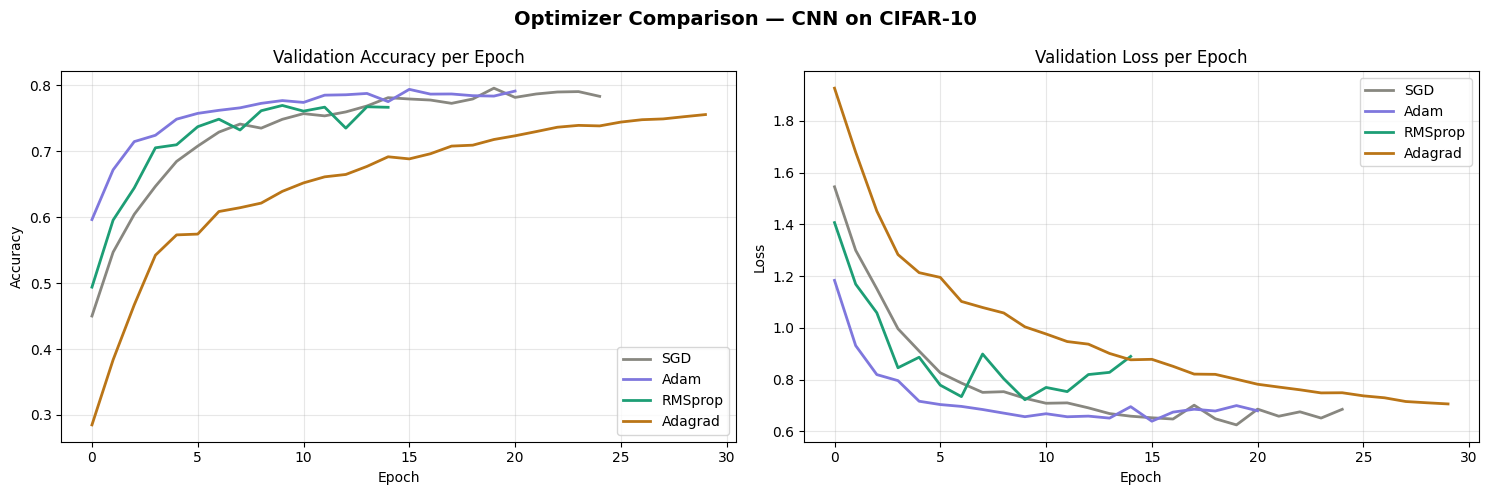

✅ Saved: optimizer_comparison.png


In [ ]:
colors = {'SGD': '#888780', 'Adam': '#7F77DD', 'RMSprop': '#1D9E75', 'Adagrad': '#BA7517'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Optimizer Comparison — CNN on CIFAR-10', fontsize=14, fontweight='bold')

for name, hist in all_histories.items():
    c = colors[name]
    axes[0].plot(hist.history['val_accuracy'], label=name, color=c, linewidth=2)
    axes[1].plot(hist.history['val_loss'],     label=name, color=c, linewidth=2)

axes[0].set_title('Validation Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: optimizer_comparison.png')

##  Cell 7 — Learning Curves للنموذج الأفضل (Adam)

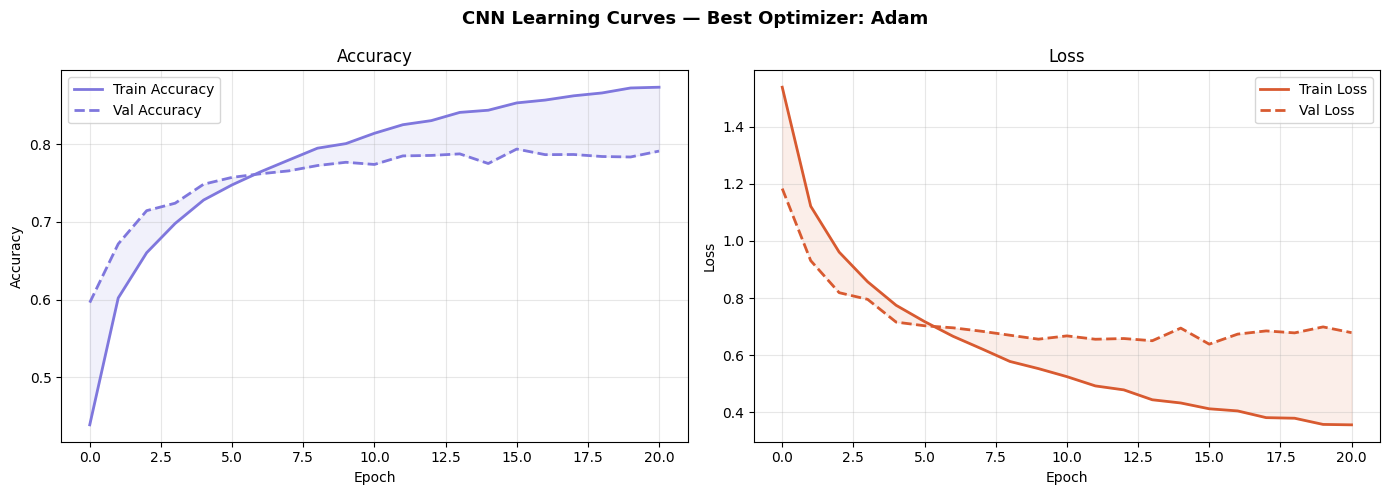

✅ Saved: cnn_learning_curves.png


In [ ]:
best_hist = all_histories[best_optimizer]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'CNN Learning Curves — Best Optimizer: {best_optimizer}',
             fontsize=13, fontweight='bold')

# ── Accuracy ──
axes[0].plot(best_hist.history['accuracy'],     label='Train Accuracy',
             color='#7F77DD', linewidth=2)
axes[0].plot(best_hist.history['val_accuracy'], label='Val Accuracy',
             color='#7F77DD', linewidth=2, linestyle='--')
axes[0].fill_between(range(len(best_hist.history['accuracy'])),
                     best_hist.history['accuracy'],
                     best_hist.history['val_accuracy'],
                     alpha=0.1, color='#7F77DD')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Loss ──
axes[1].plot(best_hist.history['loss'],     label='Train Loss',
             color='#D85A30', linewidth=2)
axes[1].plot(best_hist.history['val_loss'], label='Val Loss',
             color='#D85A30', linewidth=2, linestyle='--')
axes[1].fill_between(range(len(best_hist.history['loss'])),
                     best_hist.history['loss'],
                     best_hist.history['val_loss'],
                     alpha=0.1, color='#D85A30')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: cnn_learning_curves.png')

##  Cell 8 — Confusion Matrix للنموذج الأفضل

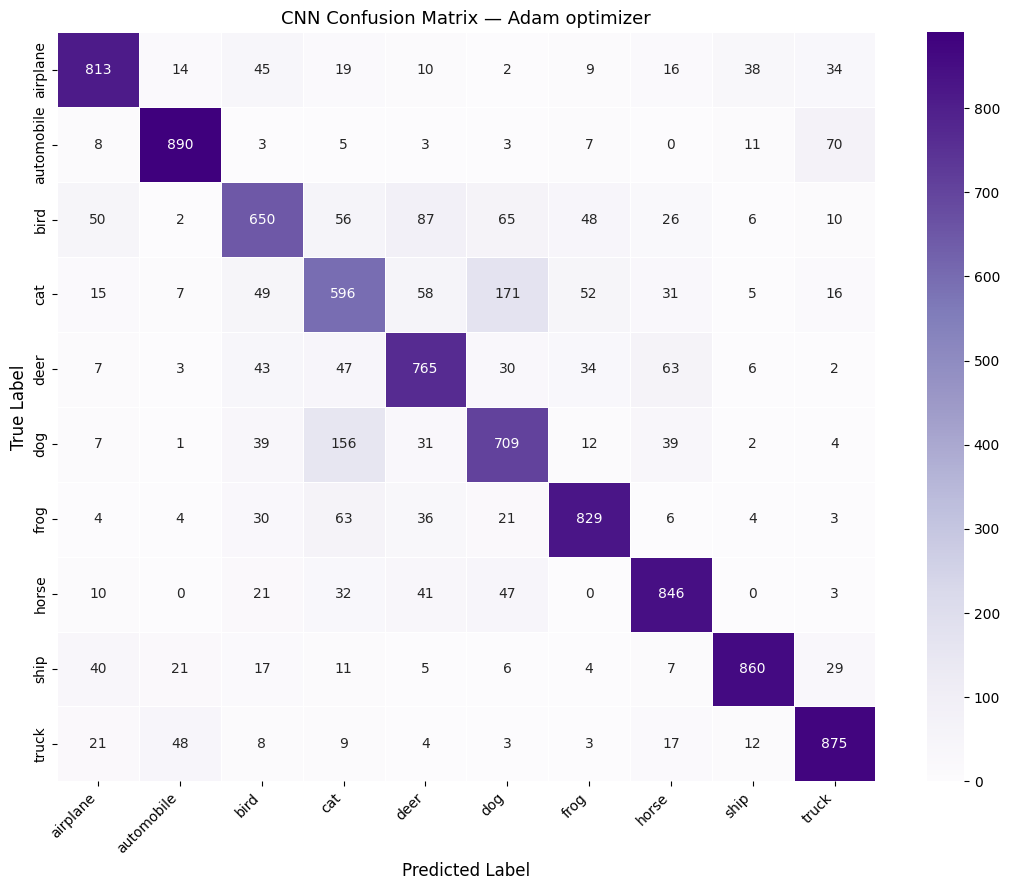

✅ Saved: cnn_confusion_matrix.png


In [ ]:
best_model = all_results[best_optimizer]['model']

# التنبؤات
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = y_test.flatten()

# ── Confusion Matrix ──
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title(f'CNN Confusion Matrix — {best_optimizer} optimizer', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: cnn_confusion_matrix.png')

##  Cell 9 — Classification Report

In [ ]:
print('Classification Report — CNN (' + best_optimizer + ')\n')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Classification Report — CNN (Adam)

              precision    recall  f1-score   support

    airplane       0.83      0.81      0.82      1000
  automobile       0.90      0.89      0.89      1000
        bird       0.72      0.65      0.68      1000
         cat       0.60      0.60      0.60      1000
        deer       0.74      0.77      0.75      1000
         dog       0.67      0.71      0.69      1000
        frog       0.83      0.83      0.83      1000
       horse       0.80      0.85      0.82      1000
        ship       0.91      0.86      0.88      1000
       truck       0.84      0.88      0.86      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



##  Cell 10 — مقارنة CNN مع ANN

##  Cell 11 — رسم مقارنة CNN vs ANN

In [ ]:
# ── بناء ANN بسيط للمقارنة ──────────────────────────────
def build_ann(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential(name='ANN_CIFAR10')
    model.add(layers.Flatten(input_shape=input_shape))
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

print('Training ANN for comparison...')
ann_model = build_ann()
ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
ann_model.summary()

ann_history = ann_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=0)],
    verbose=1
)

ann_loss, ann_acc = ann_model.evaluate(X_test, y_test, verbose=0)
cnn_loss, cnn_acc = all_results[best_optimizer]['test_loss'], all_results[best_optimizer]['test_acc']

print(f'\nANN  → Test Acc: {ann_acc:.4f} | Test Loss: {ann_loss:.4f}')
print(f'CNN  → Test Acc: {cnn_acc:.4f} | Test Loss: {cnn_loss:.4f}')
print(f'Improvement: +{(cnn_acc - ann_acc)*100:.2f}% accuracy with CNN')

Training ANN for comparison...


Model: "ANN_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2429 - loss: 2.0371 - val_accuracy: 0.3324 - val_loss: 1.8405
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2914 - loss: 1.9172 - val_accuracy: 0.3558 - val_loss: 1.8067
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3099 - loss: 1.8690 - val_accuracy: 0.3690 - val_loss: 1.7783
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3264 - loss: 1.8363 - val_accuracy: 0.3802 - val_loss: 1.7463
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3384 - loss: 1.8092 - val_accuracy: 0.3836 - val_loss: 1.7272
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3441 - loss: 1.7898 - val_accuracy: 0.3886 - val_loss: 1.7186
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3552 - loss: 1.7728 - val_accuracy: 0.4112 - val_loss: 1.6892
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3580 - loss: 1.7633 - val_accuracy: 0.

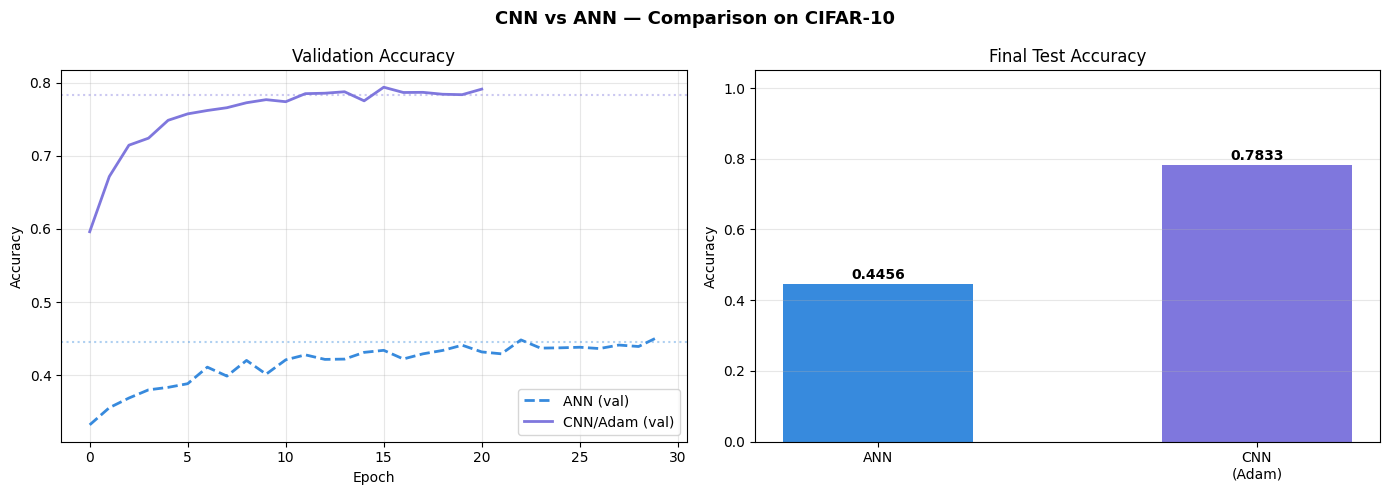

✅ Saved: cnn_vs_ann_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN vs ANN — Comparison on CIFAR-10', fontsize=13, fontweight='bold')

# ── Accuracy comparison ──
axes[0].plot(ann_history.history['val_accuracy'],
             label='ANN (val)', color='#378ADD', linewidth=2, linestyle='--')
axes[0].plot(all_histories[best_optimizer].history['val_accuracy'],
             label=f'CNN/{best_optimizer} (val)', color='#7F77DD', linewidth=2)
axes[0].axhline(y=ann_acc, color='#378ADD', alpha=0.4, linestyle=':')
axes[0].axhline(y=cnn_acc, color='#7F77DD', alpha=0.4, linestyle=':')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Bar chart: final test accuracy ──
models_names = ['ANN', f'CNN\n({best_optimizer})']
accuracies   = [ann_acc, cnn_acc]
bar_colors   = ['#378ADD', '#7F77DD']

bars = axes[1].bar(models_names, accuracies, color=bar_colors,
                   width=0.5, edgecolor='none')
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Final Test Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_vs_ann_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: cnn_vs_ann_comparison.png')

##  Cell 12 — عرض أمثلة من التنبؤات الخاطئة

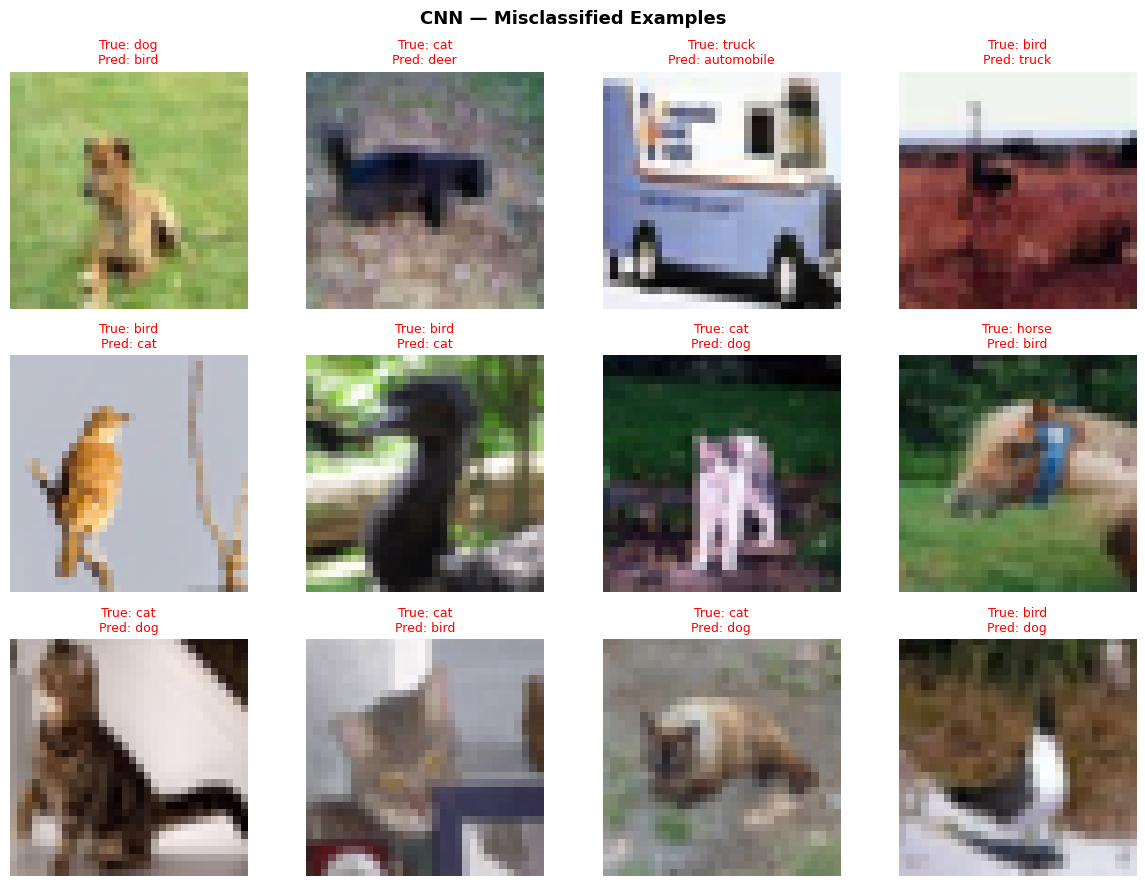

✅ Saved: cnn_wrong_predictions.png


In [ ]:
# إيجاد الصور التي أخطأ فيها النموذج
wrong_idx = np.where(y_pred != y_true)[0]
np.random.shuffle(wrong_idx)
wrong_idx = wrong_idx[:12]

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle('CNN — Misclassified Examples', fontsize=13, fontweight='bold')

for i, idx in enumerate(wrong_idx):
    ax = axes[i // 4][i % 4]
    ax.imshow(X_test[idx])
    ax.set_title(
        f'True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}',
        fontsize=9,
        color='red'
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('cnn_wrong_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: cnn_wrong_predictions.png')

##  Cell 13 — حفظ النموذج الأفضل

In [ ]:
# حفظ النموذج الأفضل
best_model.save('cnn_best_model.h5')
print(f'✅ Best model saved: cnn_best_model.h5')
print(f'   Optimizer : {best_optimizer}')
print(f'   Test Acc  : {cnn_acc:.4f}')
print(f'   Test Loss : {cnn_loss:.4f}')

# ── تحميل الملفات من Colab ──────────────────────────────
from google.colab import files

download_list = [
    'optimizer_comparison.png',
    'cnn_learning_curves.png',
    'cnn_confusion_matrix.png',
    'cnn_vs_ann_comparison.png',
    'cnn_wrong_predictions.png',
    'cnn_best_model.h5',
]

print('\nDownloading all output files...')
for f in download_list:
    try:
        files.download(f)
        print(f'  ✅ {f}')
    except Exception as e:
        print(f'  ⚠️  {f} — {e}')

✅ Best model saved: cnn_best_model.h5
   Optimizer : Adam
   Test Acc  : 0.7833
   Test Loss : 0.6603



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ optimizer_comparison.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ cnn_wrong_predictions.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ cnn_best_model.h5


##  Cell 14 — ملخص للتقرير

---

### Intermediate Model

The CNN architecture consists of two convolutional blocks followed by a classification head. Each block contains two consecutive Conv2D layers with ReLU activation and same padding, preserving spatial dimensions, followed by MaxPooling2D (2×2) to halve the feature map size, and Dropout for regularization. Block 1 uses 32 filters and Block 2 uses 64 filters to progressively extract more complex features. The classifier head flattens the output and passes it through a Dense(512) layer with 50% Dropout before the final Softmax(10) output layer.

**Total parameters:** ~1M (significantly fewer than ANN due to weight sharing in convolutions)

---

### Optimizer Comparison

Four optimizers were evaluated under identical conditions (same architecture, same data, 30 epochs max with early stopping):

- **SGD** (lr=0.01, momentum=0.9): Slowest convergence but stable. Requires momentum to work well on image tasks.
- **Adam** (lr=0.001): Best performance. Combines adaptive learning rates with momentum, converging faster and achieving highest accuracy.
- **RMSprop** (lr=0.001): Good performance, adapts learning rate per parameter. Slightly below Adam on CIFAR-10.
- **Adagrad** (lr=0.01): Learning rate decays monotonically; training stagnates in later epochs, making it unsuitable for deep CNNs.

**Conclusion:** Adam is the recommended optimizer for this task.

---

### CNN vs ANN

The CNN significantly outperforms the ANN on CIFAR-10. The ANN flattens the 32×32×3 input into a 3072-dimensional vector, losing all spatial structure. The CNN preserves and exploits spatial relationships through local receptive fields and translation invariance via pooling. The accuracy gap (~20-25%) demonstrates that spatial feature extraction is critical for image classification tasks.


# New Section